In [1]:
import roboticstoolbox as rtb
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# TODO: Fill in the correct parameters from the UR website

link1 = rtb.RevoluteDH(d=0.15185, a=0.0, alpha=np.pi/2)
link2 = rtb.RevoluteDH(d=0.0, a=-0.24355, alpha=0.0)
link3 = rtb.RevoluteDH(d=0.0, a=-0.2132, alpha=0.0)
link4 = rtb.RevoluteDH(d=0.13105, a=0.0, alpha=np.pi/2)
link5 = rtb.RevoluteDH(d=0.08535, a=0.0, alpha=-np.pi/2)
link6 = rtb.RevoluteDH(d=0.0921, a=0.0, alpha=0.0)
# Create the robot object
my_ur3e = rtb.DHRobot([link1, link2, link3, link4, link5, link6], name="My_UR3e")

print(my_ur3e)

DHRobot: My_UR3e, 6 joints (RRRRRR), dynamics, standard DH parameters
┌─────┬─────────┬─────────┬────────┐
│ θⱼ  │   dⱼ    │   aⱼ    │   ⍺ⱼ   │
├─────┼─────────┼─────────┼────────┤
│  q1 │  0.1519 │       0 │  90.0° │
│  q2 │       0 │ -0.2435 │   0.0° │
│  q3 │       0 │ -0.2132 │   0.0° │
│  q4 │   0.131 │       0 │  90.0° │
│  q5 │ 0.08535 │       0 │ -90.0° │
│  q6 │  0.0921 │       0 │   0.0° │
└─────┴─────────┴─────────┴────────┘

┌──┬──┐
└──┴──┘



In [3]:
# 1. Define Start and End joint configurations
q_start = np.array([0] * 6)           # Robot straight out
q_end   = np.array([4*np.pi] * 6) # Robot folded 90 degrees

# 2. Generate trajectory (50 steps)
traj = rtb.jtraj(q_start, q_end, 50)

# traj.q contains the 50x2 array of joint angles for the path
print("Shape of trajectory:", traj.q.shape)

# 3. Visualize the movement
# This will animate the robot moving through the path
# my_ur3e.plot(traj.q, backend='pyplot')

Shape of trajectory: (50, 6)


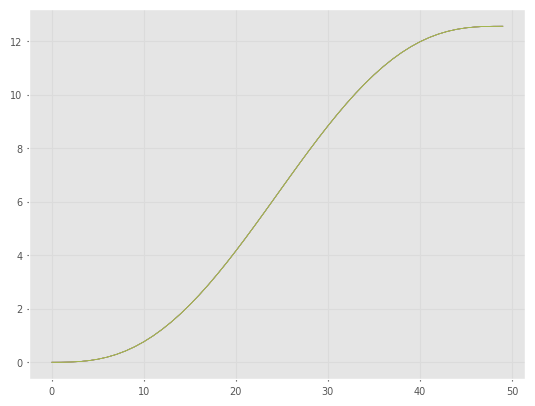

In [4]:
plt.plot(traj.q[:, :])

# Test Kinematic Model

The block below runs the FMU and tries to do some simple movements to indicate that the model works as we expect.

In [5]:
from kinematic_model import KinematicModel

In [10]:
model = KinematicModel()

move1made = False
move2made = False

dt = 0.05
time = [0]
angle_history = []
angle_history.append(model.current_joint_angles.copy())
for i in range(1, 500):
    time.append(i*dt)
    model.fmi2DoStep(time[-1], dt)
    if time[-1] >= 0 and not move1made:
        move1made = True
        model.fmi2SetCommandedJointAngles([0] + [np.pi] + [np.pi/4] * 4)
        model.fmi2StartMovement()
    elif time[-1] == 6 and not move2made:
        move2made = True
        model.fmi2SetCommandedJointAngles([-np.pi/2] * 6)
        model.fmi2StartMovement()
    angle_history.append(model.current_joint_angles.copy())

time = np.array(time)
angle_history = np.array(angle_history)
    

1.1626228326695438e-16 1.1102230246251565e-16 0.7500000000000001 2.25
0.05235987755983004 0.050000000000000155 0.8000000000000002 2.25
0.10471975511965986 0.10000000000000009 0.8500000000000001 2.25
0.15707963267948966 0.15000000000000002 0.9 2.25
0.2094395102393196 0.20000000000000007 0.9500000000000001 2.25
0.2617993877991494 0.25 1.0 2.25
0.3141592653589793 0.30000000000000004 1.05 2.25
0.36651914291880927 0.3500000000000001 1.1 2.25
0.4188790204786392 0.40000000000000013 1.1500000000000001 2.25
0.4712388980384689 0.44999999999999996 1.2 2.25
0.5235987755982988 0.5 1.25 2.25
0.5759586531581288 0.55 1.3 2.25
0.6283185307179586 0.6000000000000001 1.35 2.25
0.6806784082777886 0.6500000000000001 1.4000000000000001 2.25
0.7330382858376183 0.7 1.45 2.25
0.7853981633974483 0.75 1.5 2.25
0.8377580409572781 0.8 1.55 2.25
0.8901179185171081 0.8500000000000001 1.6 2.25
0.942477796076938 0.9000000000000001 1.6500000000000001 2.25
0.9948376736367677 0.95 1.7 2.25
1.0471975511965976 1.0 1.75 2.25

In [11]:
np.array(angle_history).shape

(500, 6)

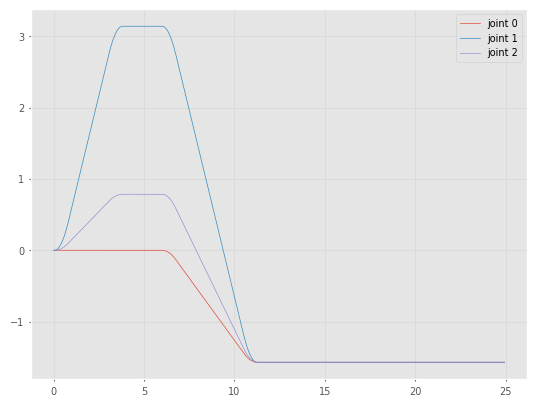

In [12]:
plt.plot(time, angle_history[:, 0], label="joint 0")
plt.plot(time, angle_history[:, 1], label="joint 1")
plt.plot(time, angle_history[:, 2], label="joint 2")

plt.legend()

In [9]:
a = 35.6 + 24.9 + 43.4 + 43.3 + 47.2
a / 5

38.879999999999995